In [1]:
from aisam.model import models
from aisam.utils import aux
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import json

params = {}
params['delta'] = 0.01
params['alpha'] = 1
params['beta'] = 1
params['k'] = 0.4851
params['k_tet'] = 5
params['h1'] = 2.3435*0.0303
params['h2'] = 0.0303
params['tau_delay'] = 12
params['n']=3.6
params['n_tet'] = 2
params['c2'] = 0.0631
params['t_max'] = 960
params['sampling'] = 10
    


In [7]:
from aisam.model import sims
from aisam.utils import aux

xpt = sims.experiment(params,'ccasr')

t_max = 960 #16 h
num_cells = 10
stims = {}
for i in range(10):
    np.random.seed(10*i+10)
    num_stims = t_max / 5
    stims[f'cell {i+1}'] = aux.repetitive_stim_maker(i+1,int((t_max)/5),True)
    #np.concatenate([[0]* 36 ,  aux.repetitive_stim_maker(i+1,int((t_max-36)/5))])


xpt.init_exp(num_cells)
Res = xpt.run_training_sim(stims,3)

ccasr simulation: 100%|██████████| 10/10 [00:54<00:00,  5.45s/cell]


(3, 9600)


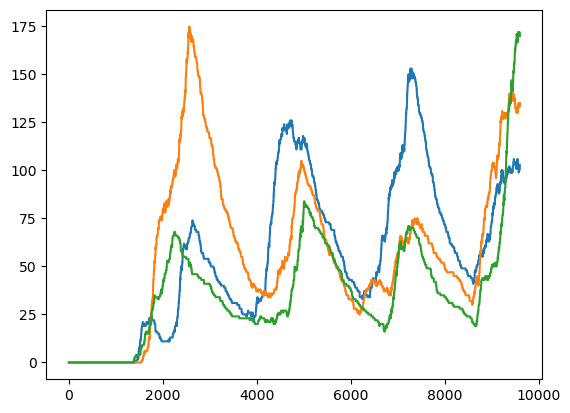

In [8]:
print((xpt.Cells['2'].expressions['F'][0].shape))
for i in range(3):
    plt.plot((xpt.Cells['8'].expressions['F'][0][i,:]))

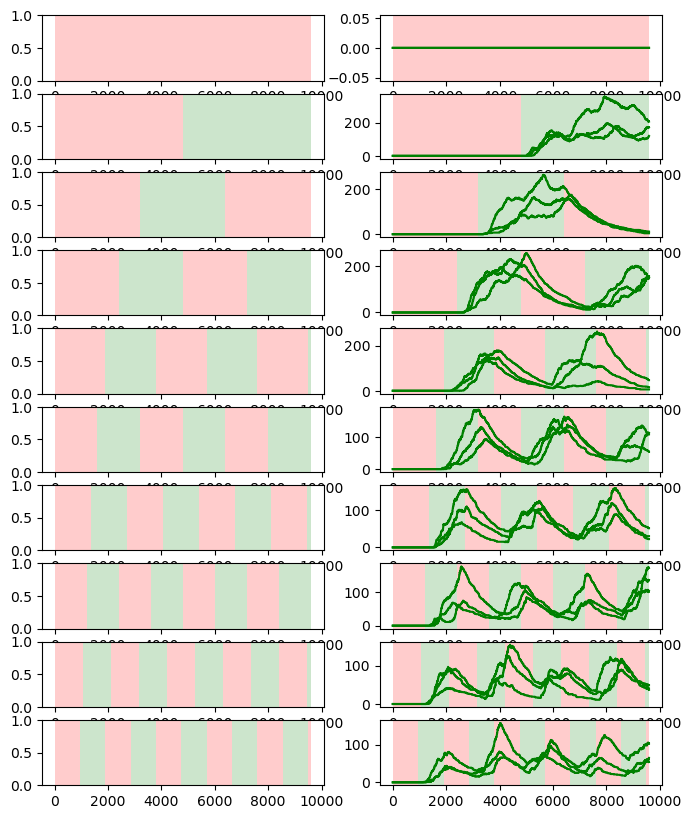

In [14]:
fig,ax = plt.subplots(10,2,figsize = (8,10))
for i in range(10):
    aux.background_plotter(ax[i][0],stims[f'cell {i+1}'])
    aux.background_plotter(ax[i][1],stims[f'cell {i+1}'])
    for j in range(3):
        #ax[i][0].plot(Res[f'cell {i+1}'][j]['T'],color = 'b')
        ax[i][1].plot(xpt.Cells[f'{i+1}'].expressions['F'][0][j,:],color = 'g')


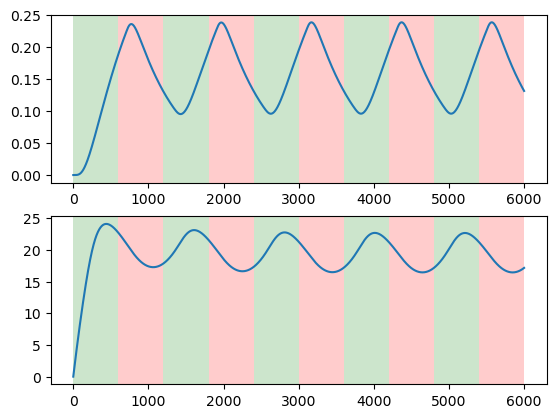

In [ ]:
params = {}
params['delta'] = 0.016
params['alpha'] = 0.01
params['beta'] = 1
params['k'] = 0.4851
params['k_tet'] = 0.1
params['h1'] = 2.3435*0.0303
params['h2'] = 0.0303
params['tau_delay'] = 12
params['n']=3.6
params['n_tet'] = 2
params['c2'] = 0.0631
    

model = models.ODE_CcaSR_Inverter(params,600)
stim = aux.repetitive_stim_maker(10,120)
x = model.solve(stim,[0,0,0])
fig , ax = plt.subplots(2,1)
for i in range(2):
    aux.background_plotter(ax[i],stim)
    ax[i].plot(x[:,i+1])

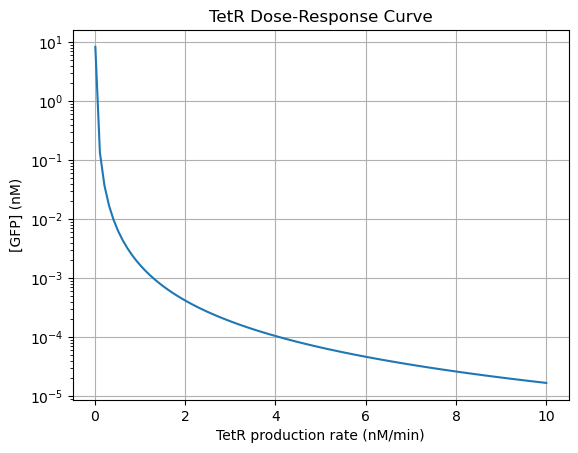

In [ ]:
from matplotlib import pyplot as plt
import numpy as np


delta = 0.05
delta_gfp = 0.03
alpha_Y = 0.5

ktetWT = 0.2
ktet6 = 2

def Y_calc(alpha_T,ktetWT,alpha_Y,delta,delta_GFP):
    T_total = alpha_T/delta
    Y = (alpha_Y/(1+(T_total/ktetWT)**2))/delta_GFP
    return Y

alpha_T = np.linspace(0.01,10,100,endpoint=True)

Y = np.zeros_like(alpha_T)

for i,alpha in enumerate(alpha_T):
    Y[i] = Y_calc(alpha,ktetWT,alpha_Y,delta,delta_gfp)
    
plt.plot(alpha_T,Y)
plt.yscale('log')
plt.xlabel('TetR production rate (nM/min)')
plt.ylabel('[GFP] (nM)')
plt.title('TetR Dose-Response Curve')
plt.grid(True)
plt.show()



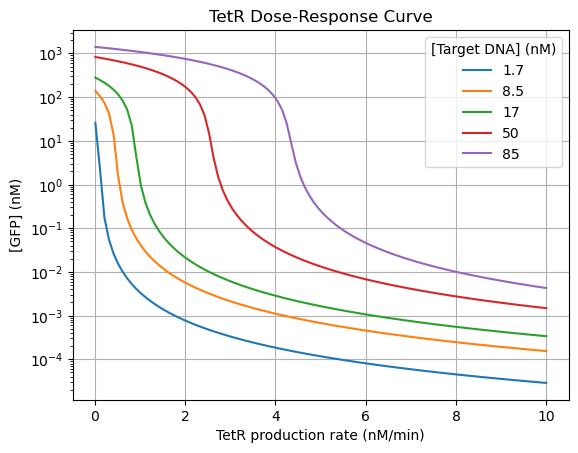

In [ ]:
from scipy.optimize import brentq

delta = 0.05
delta_gfp = 0.03
alpha_Y = 0.5

ktetWT = 0.2
ktet6 = 2
D_T = 17

def tet_equation(T,T_total,D_T,ktet):
    if T<0: T=0
    occupied_Tet = D_T * ((T/ktet)**2/(1+(T/ktet)**2))
    return T + occupied_Tet - T_total


def Y_calc(alpha_T,ktetWT,alpha_Y,D_T,delta,delta_GFP):
    T_total = alpha_T/delta
    eq_sol = brentq(tet_equation,0,T_total,args=(T_total,D_T,ktetWT))
    T_free = eq_sol
    unoccupied_DNA = D_T * (1/(1+(T_free/ktetWT)**2))
    Y = alpha_Y * unoccupied_DNA/delta_GFP
    return Y

alpha_T = np.linspace(0.01,10,100,endpoint=True)

Y = np.zeros_like(alpha_T)

for D_T in [1.7,8.5,17,50,85]:
    for i,alpha in enumerate(alpha_T):
        Y[i] = Y_calc(alpha,ktetWT,alpha_Y,D_T,delta,delta_gfp)
    
    plt.plot(alpha_T,Y,label = f'{D_T}')
    plt.yscale('log')
    plt.legend(title='[Target DNA] (nM)')
plt.xlabel('TetR production rate (nM/min)')
plt.ylabel('[GFP] (nM)')
plt.title('TetR Dose-Response Curve')
plt.grid(True)
plt.show()


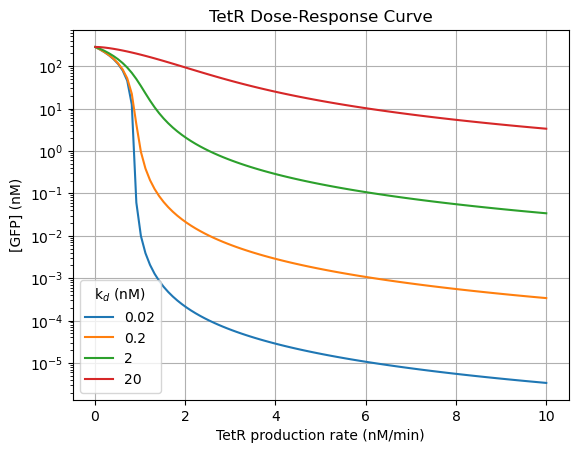

In [ ]:
from scipy.optimize import brentq

delta = 0.05
delta_gfp = 0.03
alpha_Y = 0.5

ktetWT = 0.2
ktet6 = 2
D_T = 17

def tet_equation(T,T_total,D_T,ktet):
    if T<0: T=0
    occupied_Tet = D_T * ((T/ktet)**2/(1+(T/ktet)**2))
    return T + occupied_Tet - T_total


def Y_calc(alpha_T,ktetWT,alpha_Y,D_T,delta,delta_GFP):
    T_total = alpha_T/delta
    eq_sol = brentq(tet_equation,0,T_total,args=(T_total,D_T,ktetWT))
    T_free = eq_sol
    unoccupied_DNA = D_T * (1/(1+(T_free/ktetWT)**2))
    Y = alpha_Y * unoccupied_DNA/delta_GFP
    return Y

alpha_T = np.linspace(0.01,10,100,endpoint=True)

Y = np.zeros_like(alpha_T)

for ktetWT in [0.02,0.2,2,20]:
    for i,alpha in enumerate(alpha_T):
        Y[i] = Y_calc(alpha,ktetWT,alpha_Y,D_T,delta,delta_gfp)
    
    plt.plot(alpha_T,Y,label = f'{ktetWT}')
    plt.yscale('log')
    plt.legend(title=r'k$_{d}$ (nM)')
plt.xlabel('TetR production rate (nM/min)')
plt.ylabel('[GFP] (nM)')
plt.title('TetR Dose-Response Curve')
plt.grid(True)
plt.show()

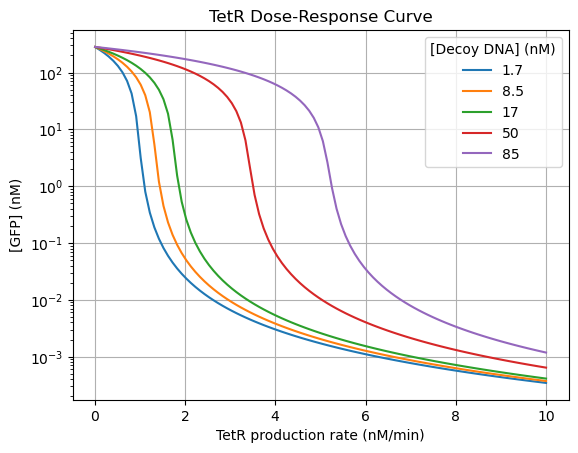

In [ ]:
from scipy.optimize import brentq

delta = 0.05
delta_gfp = 0.03
alpha_Y = 0.5

ktetWT = 0.2
ktet6 = 2
D_T = 17

def tet_equation(T,T_total,D_T,S_T,ktet):
    if T<0: T=0
    occupied_Tet = D_T * ((T/ktet)**2/(1+(T/ktet)**2))
    sequestered_Tet = S_T * ((T/ktet)**2/(1+(T/ktet)**2))
    return T + occupied_Tet + sequestered_Tet - T_total


def Y_calc(alpha_T,ktetWT,alpha_Y,D_T,S_T,delta,delta_GFP):
    T_total = alpha_T/delta
    eq_sol = brentq(tet_equation,0,T_total,args=(T_total,D_T,S_T,ktetWT))
    T_free = eq_sol
    unoccupied_DNA = D_T * (1/(1+(T_free/ktetWT)**2))
    Y = alpha_Y * unoccupied_DNA/delta_GFP
    return Y

alpha_T = np.linspace(0.01,10,100,endpoint=True)

Y = np.zeros_like(alpha_T)

for S_T in [1.7,8.5,17,50,85]:
    for i,alpha in enumerate(alpha_T):
        Y[i] = Y_calc(alpha,ktetWT,alpha_Y,D_T,S_T,delta,delta_gfp)
    
    plt.plot(alpha_T,Y,label = f'{S_T}')
    plt.yscale('log')
    plt.legend(title='[Decoy DNA] (nM)')
plt.xlabel('TetR production rate (nM/min)')
plt.ylabel('[GFP] (nM)')
plt.title('TetR Dose-Response Curve')
plt.grid(True)
plt.show()

K Value (nM)    | Final GFP (Steady State) 
---------------------------------------------
0.1             | 0.00                     
1.0             | 0.21                     
10.0            | 19.61                    
50.0            | 203.25                   


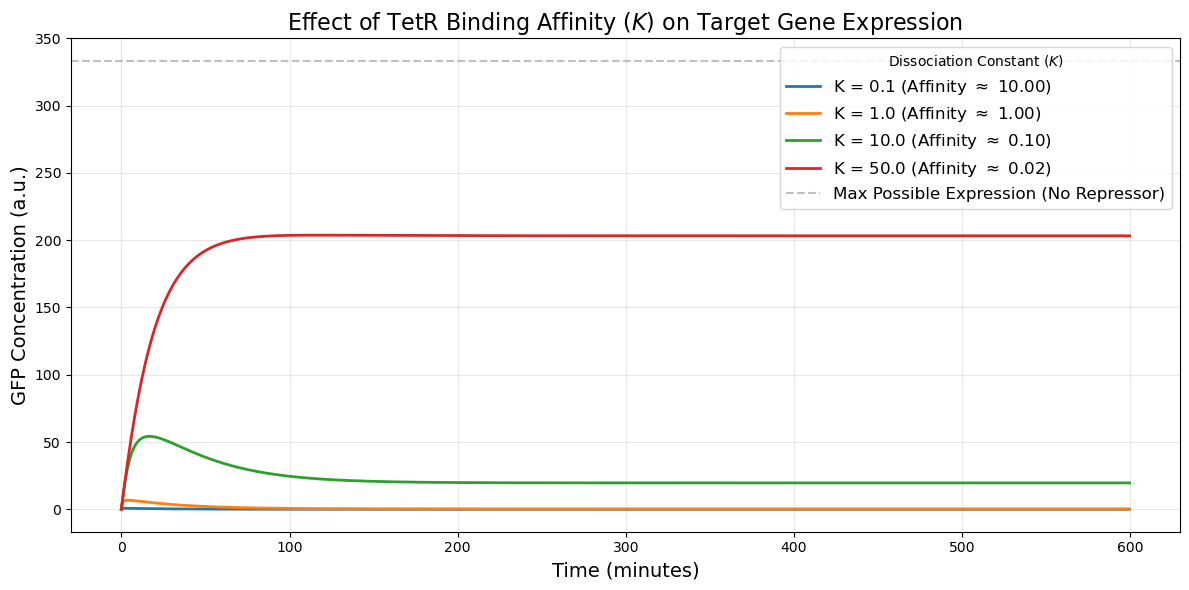

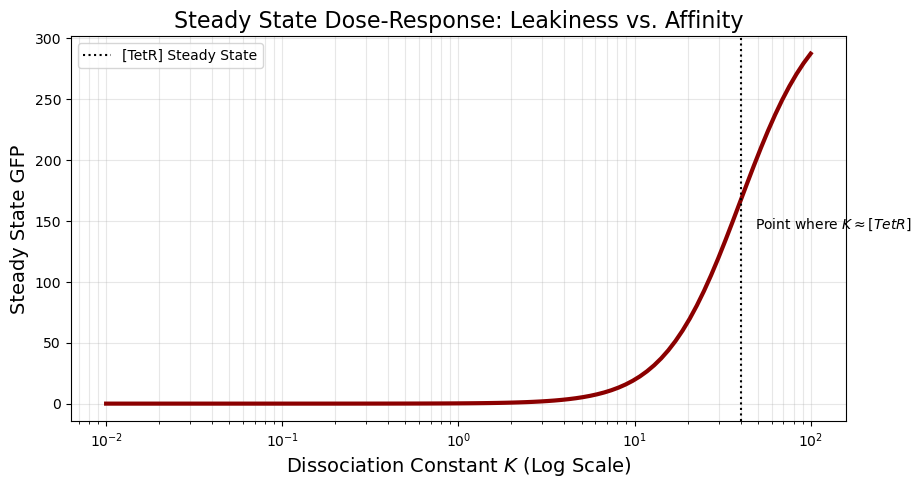

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# --- 1. Define the Model Parameters ---
# Time settings
t_max = 600       # Total simulation time (e.g., minutes)
dt = 0.5          # Time step
t = np.arange(0, t_max, dt)

# Biological constants (arbitrary units for demonstration)
alpha_tetR = 2.0  # Production rate of TetR
delta_tetR = 0.05 # Degradation rate of TetR

alpha_GFP = 10.0  # Max production rate of GFP (Target Gene)
delta_GFP = 0.03  # Degradation rate of GFP
n = 2.0           # Hill coefficient (cooperativity of TetR dimer binding)

# List of K values to test (Dissociation Constants)
# Note: Lower K = Higher Affinity
K_values = [0.1, 1.0, 10.0, 50.0]

# --- 2. Define the Differential Equations ---
def model(y, t, K, alpha_tetR, delta_tetR, alpha_GFP, delta_GFP, n):
    """
    y[0] = [TetR] concentration
    y[1] = [GFP] concentration
    """
    TetR, GFP = y
    
    # ODE 1: TetR Dynamics (Constitutive expression)
    dTetR_dt = alpha_tetR - delta_tetR * TetR
    
    # ODE 2: GFP Dynamics (Regulated by TetR via Hill Function)
    # The repression term is: 1 / (1 + (TetR/K)^n)
    # When TetR is high, production -> 0. When TetR is low, production -> alpha_GFP.
    repression_strength = 1.0 / (1.0 + (TetR / K)**n)
    dGFP_dt = (alpha_GFP * repression_strength) - (delta_GFP * GFP)
    
    return [dTetR_dt, dGFP_dt]

# --- 3. Run Simulation for Each K Value ---
plt.figure(figsize=(12, 6))

# Initial conditions: [TetR]=0, [GFP]=0 at start
y0 = [0.0, 0.0]

print(f"{'K Value (nM)':<15} | {'Final GFP (Steady State)':<25}")
print("-" * 45)

for K in K_values:
    # Solve ODE
    solution = odeint(model, y0, t, args=(K, alpha_tetR, delta_tetR, alpha_GFP, delta_GFP, n))
    
    tetR_conc = solution[:, 0]
    gfp_conc = solution[:, 1]
    
    # Print steady state results
    print(f"{K:<15} | {gfp_conc[-1]:<25.2f}")
    
    # Plotting
    plt.plot(t, gfp_conc, label=f'K = {K} (Affinity $\\approx$ {1/K:.2f})', linewidth=2)

# --- 4. Format and Display Plot ---
plt.title("Effect of TetR Binding Affinity ($K$) on Target Gene Expression", fontsize=16)
plt.xlabel("Time (minutes)", fontsize=14)
plt.ylabel("GFP Concentration (a.u.)", fontsize=14)
plt.axhline(y=alpha_GFP/delta_GFP, color='grey', linestyle='--', alpha=0.5, label='Max Possible Expression (No Repressor)')
plt.grid(True, alpha=0.3)
plt.legend(title="Dissociation Constant ($K$)", fontsize=12)
plt.tight_layout()

plt.show()

# --- 5. (Optional) Generate a Dose-Response Curve (Steady State) ---
# This visualizes how "tight" the repression is across a continuous range of K
k_range = np.logspace(-2, 2, 100) # K values from 0.01 to 100
steady_state_tetR = alpha_tetR / delta_tetR
steady_state_gfp = []

for k_val in k_range:
    # Steady state formula derived from dGFP/dt = 0
    # GFP_ss = (alpha / delta) * (1 / (1 + (TetR_ss / K)^n))
    repression = 1.0 / (1.0 + (steady_state_tetR / k_val)**n)
    gfp = (alpha_GFP / delta_GFP) * repression
    steady_state_gfp.append(gfp)

plt.figure(figsize=(10, 5))
plt.semilogx(k_range, steady_state_gfp, color='darkred', linewidth=3)
plt.title("Steady State Dose-Response: Leakiness vs. Affinity", fontsize=16)
plt.xlabel("Dissociation Constant $K$ (Log Scale)", fontsize=14)
plt.ylabel("Steady State GFP", fontsize=14)
plt.grid(True, which="both", alpha=0.3)
plt.axvline(x=steady_state_tetR, color='black', linestyle=':', label='[TetR] Steady State')
plt.text(steady_state_tetR * 1.2, max(steady_state_gfp)*0.5, 'Point where $K \\approx [TetR]$', fontsize=10)
plt.legend()
plt.show()

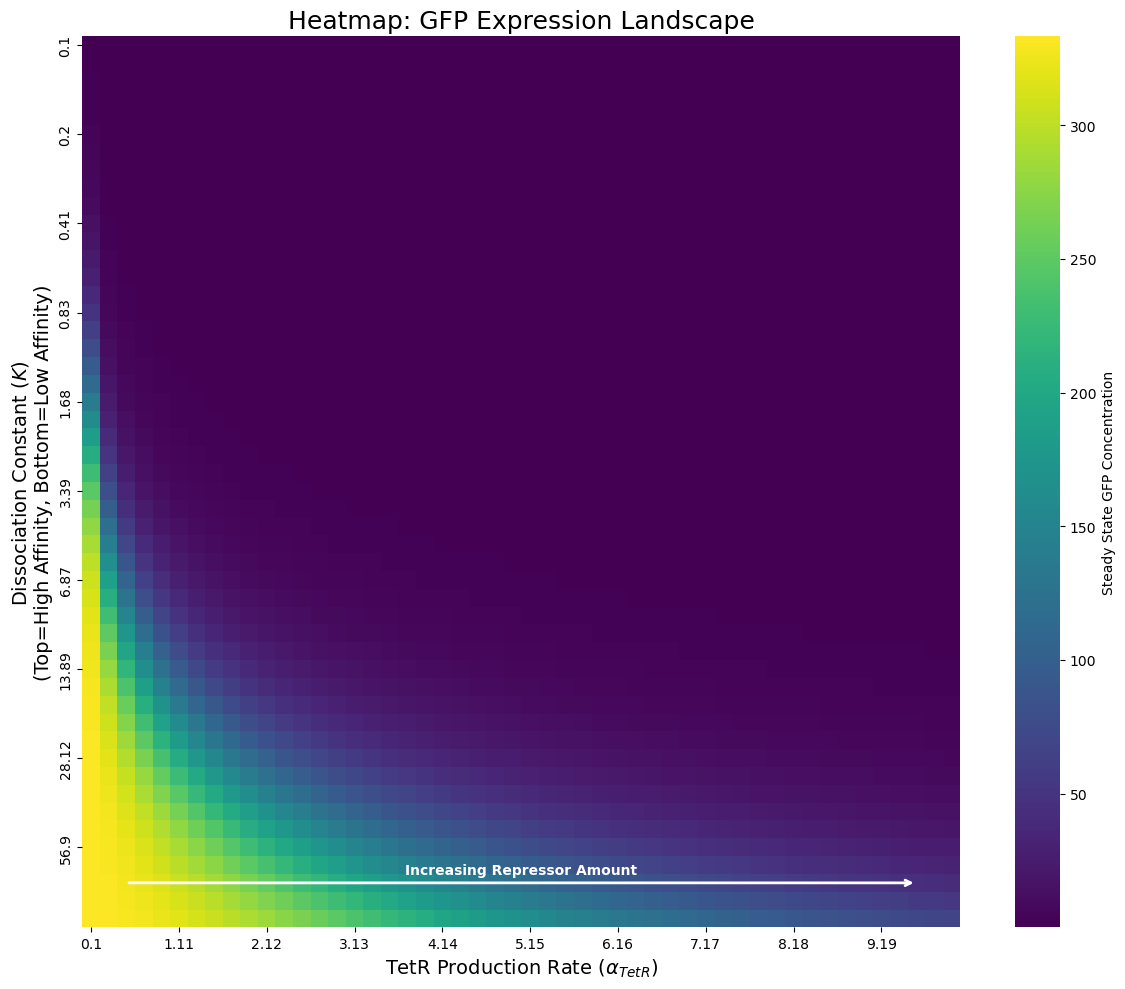

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Define Constants (Fixed Parameters) ---
delta_tetR = 0.05  # Degradation rate of TetR
alpha_GFP = 10.0   # Max production rate of GFP
delta_GFP = 0.03   # Degradation rate of GFP
n = 2.0            # Hill coefficient

# --- 2. Define Ranges for the Matrix ---
# X-axis: TetR Production Rate (Linear scale)
tetR_production_rates = np.linspace(0.1, 10.0, 50) 

# Y-axis: K Values (Logarithmic scale because affinity varies by orders of magnitude)
# 10^-1 to 10^2
k_values = np.logspace(-1, 2, 50) 

# --- 3. Generate the Data Matrix ---
# We will store results in a 2D array
gfp_steady_states = np.zeros((len(k_values), len(tetR_production_rates)))

for i, K in enumerate(k_values):
    for j, alpha_tet in enumerate(tetR_production_rates):
        
        # Calculate Steady State TetR
        # dTetR/dt = alpha - delta*TetR = 0  =>  TetR = alpha / delta
        tetR_ss = alpha_tet / delta_tetR
        
        # Calculate Steady State GFP using the Hill function
        # dGFP/dt = (alpha_gfp * repression) - delta_gfp*GFP = 0
        repression_term = 1.0 / (1.0 + (tetR_ss / K)**n)
        gfp_ss = (alpha_GFP / delta_GFP) * repression_term
        
        gfp_steady_states[i, j] = gfp_ss

# --- 4. Create a DataFrame for Easier Plotting ---
# We round the labels for cleaner axis ticks
df = pd.DataFrame(
    gfp_steady_states, 
    index=np.round(k_values, 2), 
    columns=np.round(tetR_production_rates, 2)
)

# --- 5. Plot the Heatmap ---
plt.figure(figsize=(12, 10))

# Create Heatmap
# We interpret the dataframe. Rows (index) are Y, Columns are X.
ax = sns.heatmap(
    df, 
    cmap='viridis',      # 'viridis' or 'Greens' works well here
    cbar_kws={'label': 'Steady State GFP Concentration'},
    xticklabels=5,       # Show every 5th label to avoid clutter
    yticklabels=5
)

# Invert Y axis so low K (high affinity) is at the bottom, or standard logic?
# Usually, heatmaps plot index 0 at the top. 
# Let's invert the y-axis so the plot grows upward mathematically if preferred,
# but standard matrix visualization puts (0,0) at top-left.
# We will leave it standard: Top row = Low K (0.1), Bottom row = High K (100).
# Note: Low K = Strong Repression.

plt.title("Heatmap: GFP Expression Landscape", fontsize=18)
plt.xlabel("TetR Production Rate ($\\alpha_{TetR}$)", fontsize=14)
plt.ylabel("Dissociation Constant ($K$)\n(Top=High Affinity, Bottom=Low Affinity)", fontsize=14)

# Add an arrow annotation to help interpretation
plt.annotate('', xy=(0.95, 0.05), xycoords='axes fraction', 
             xytext=(0.05, 0.05), textcoords='axes fraction',
             arrowprops=dict(arrowstyle="->", color='white', lw=2))
plt.text(0.5, 0.06, "Increasing Repressor Amount", color='white', ha='center', transform=ax.transAxes, weight='bold')

plt.tight_layout()
plt.show()

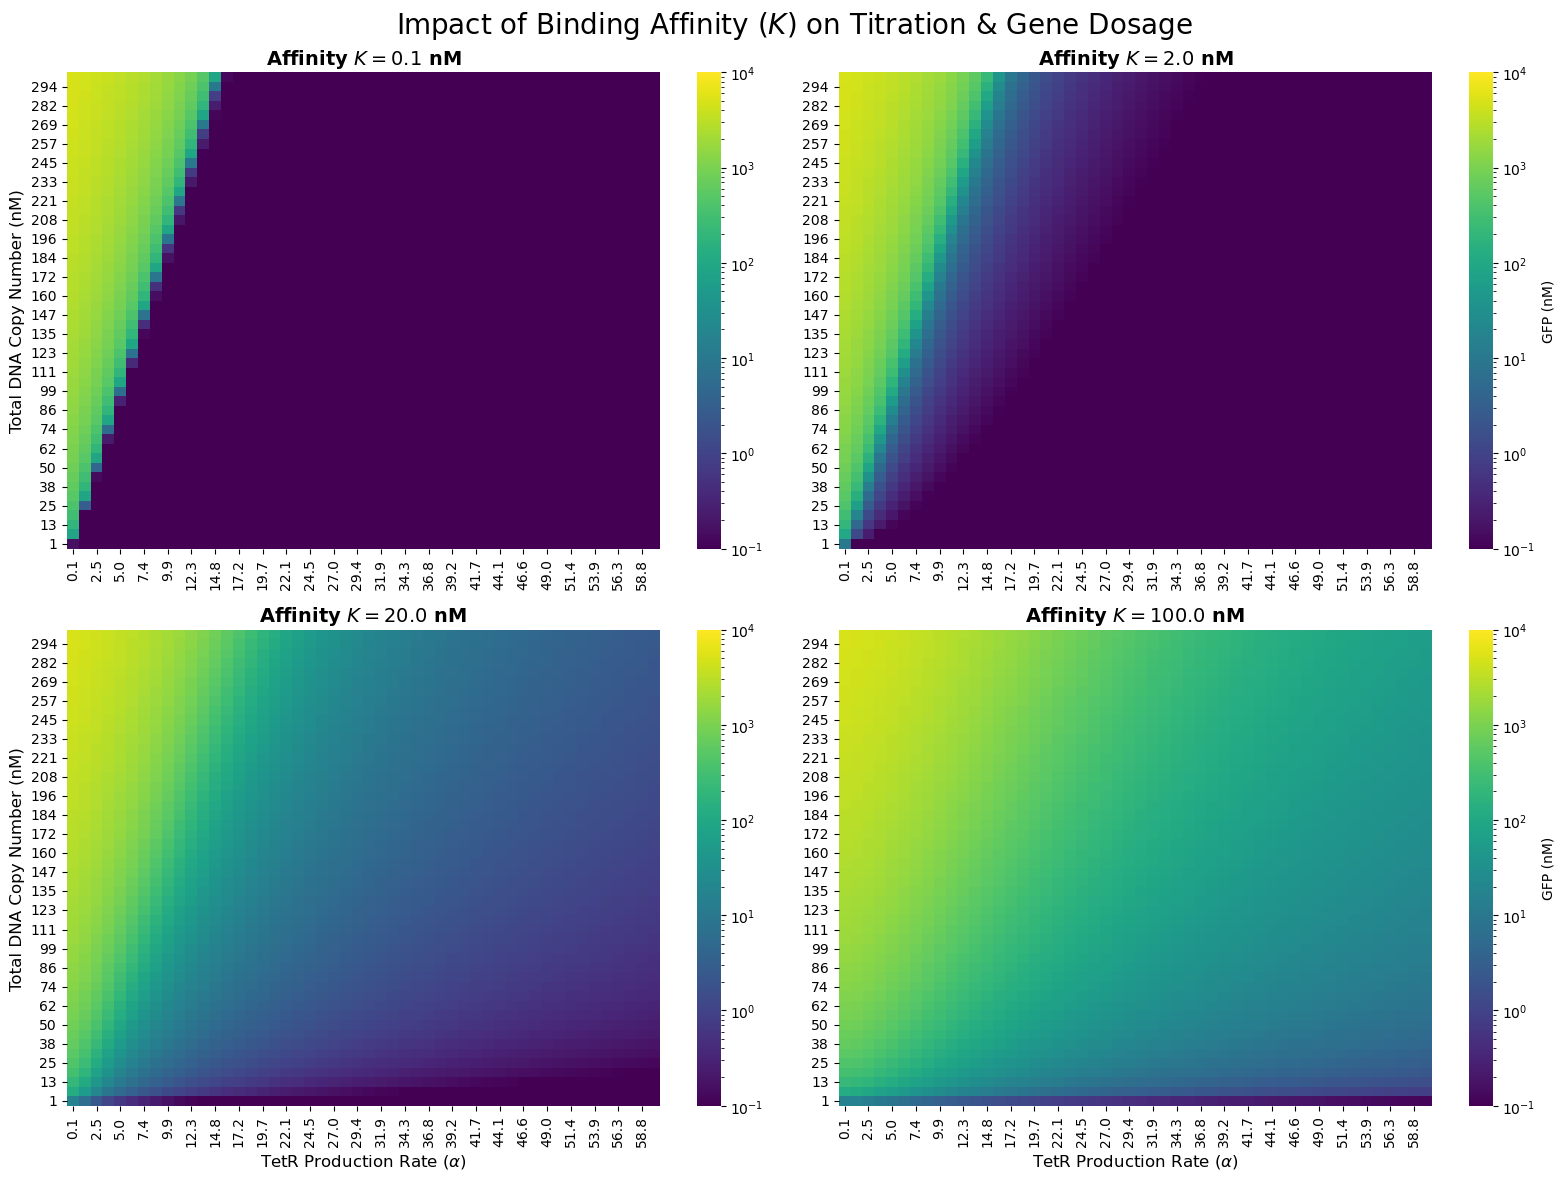

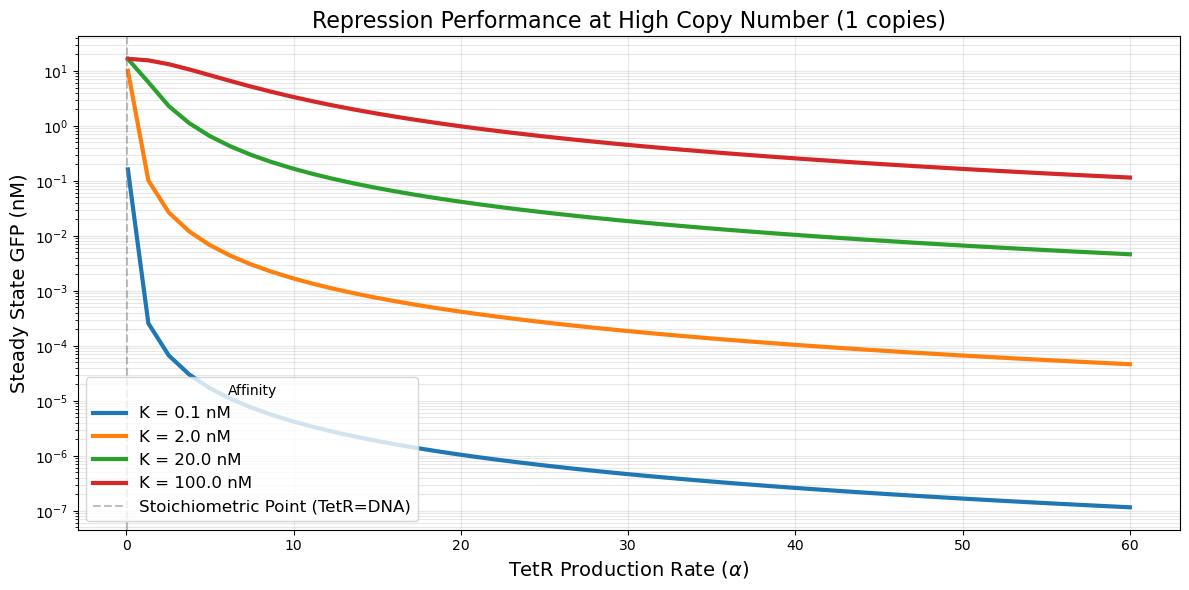

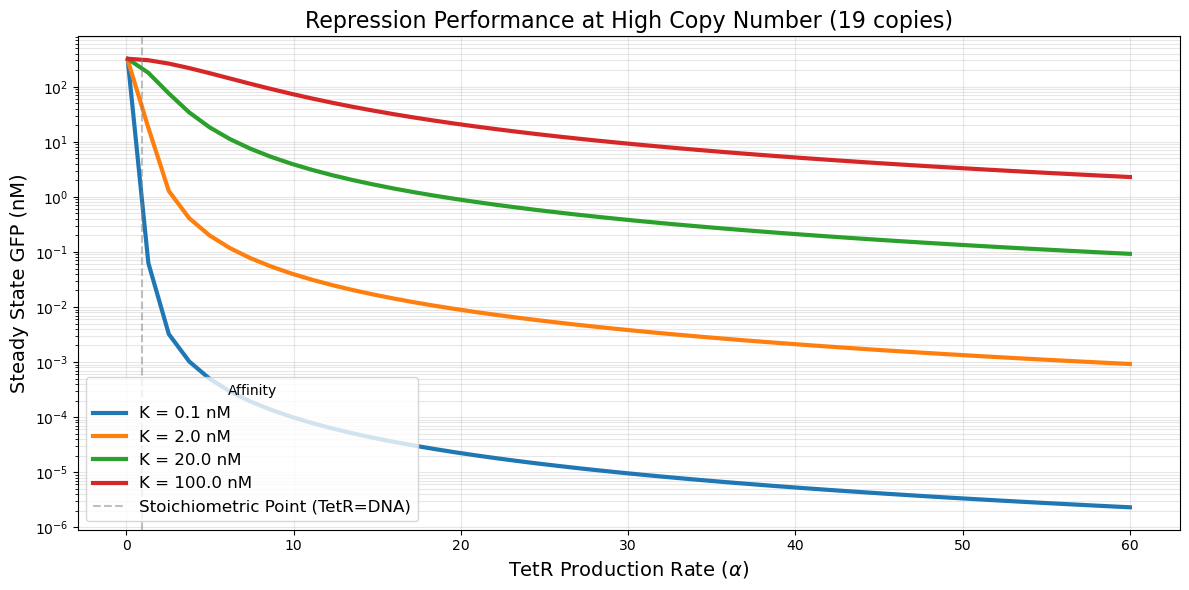

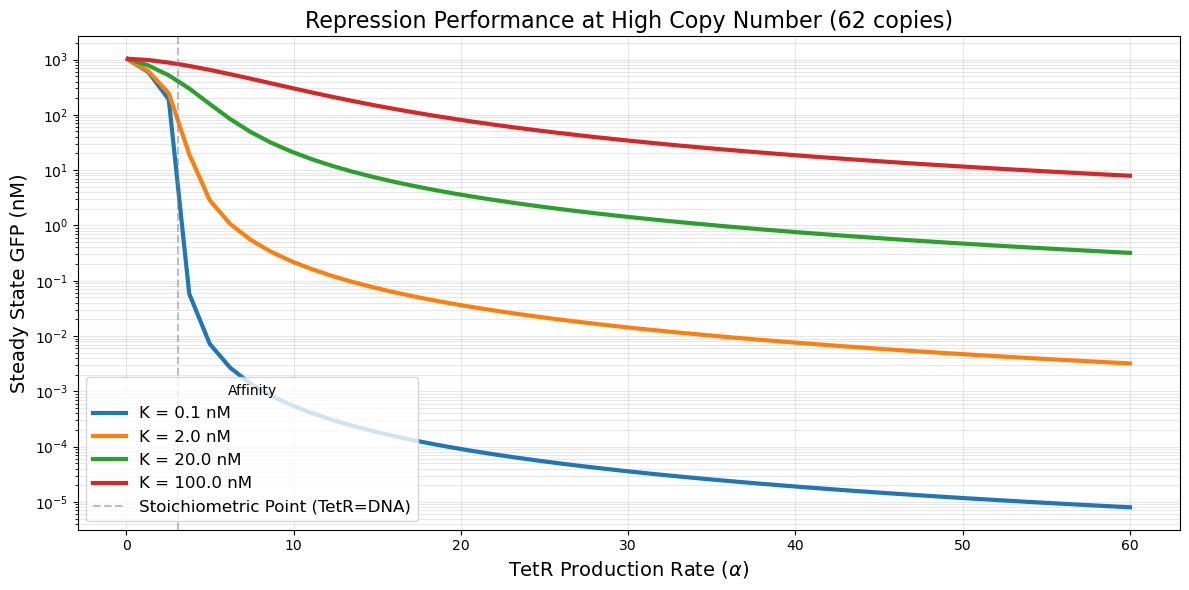

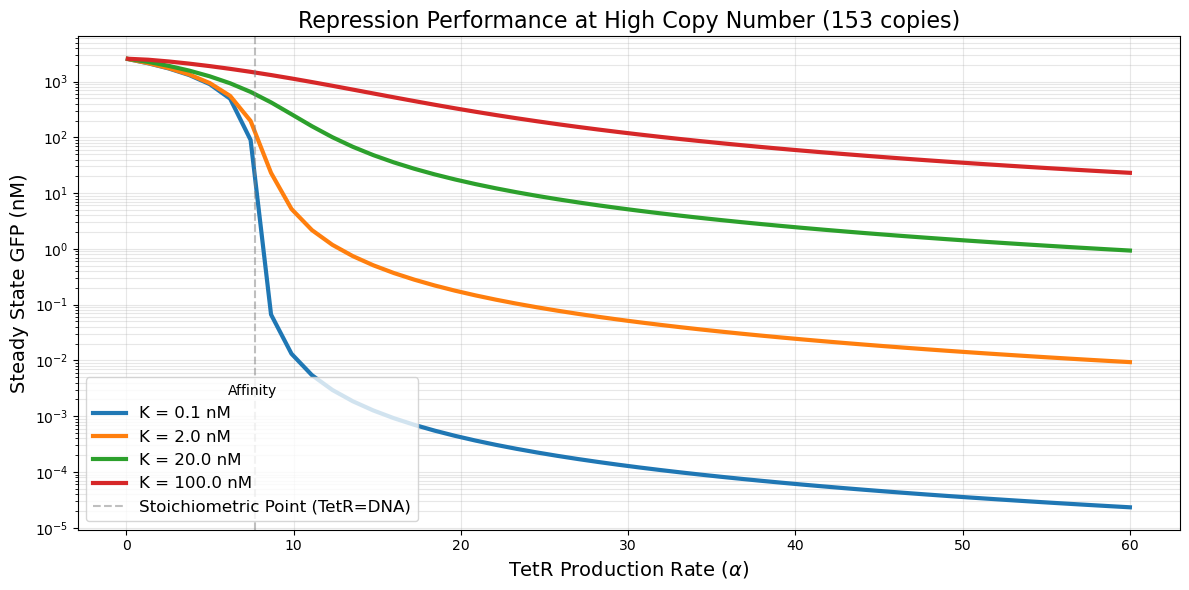

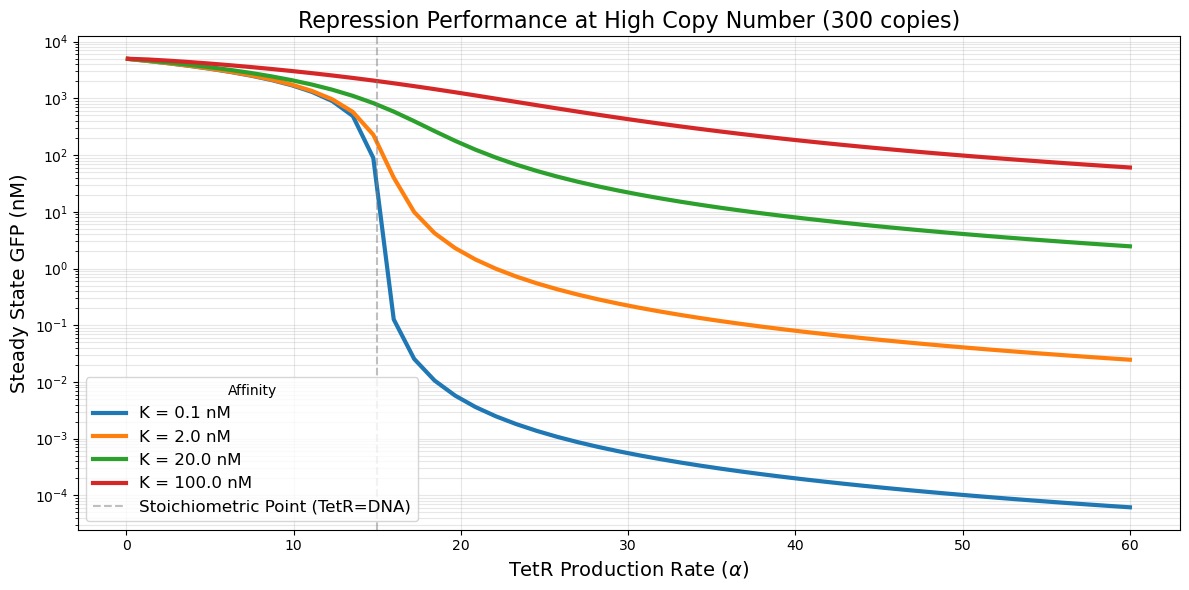

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.optimize import brentq
from matplotlib.colors import LogNorm

# --- 1. Global Parameters ---
n = 2.0                 # Hill coefficient
delta_tetR = 0.05       # Degradation rate of TetR (min^-1)
delta_GFP = 0.03        # Degradation rate of GFP (min^-1)
k_prod_per_plasmid = 0.5 # GFP production rate per DNA copy (nM/min)

# --- 2. The Solver (Robust Mass Balance) ---
def get_steady_state_gfp(alpha_tet, D_total, K):
    """
    Calculates steady state GFP given production rate, DNA amount, and Affinity.
    """
    # 1. Steady State Total TetR available
    R_total = alpha_tet / delta_tetR
    
    # 2. Solve for Free TetR (R_free) using Mass Balance
    # Equation: R_free + D_total * (R_free^n / (K^n + R_free^n)) - R_total = 0
    if R_total <= 0:
        R_free = 0.0
    else:
        def equation(r):
            occupancy = (r / K)**n / (1 + (r / K)**n)
            return r + (D_total * occupancy) - R_total
        
        try:
            R_free = brentq(equation, 0, R_total)
        except ValueError:
            R_free = 0.0

    # 3. Calculate Active DNA (Unbound)
    # Fraction unbound = 1 / (1 + (R_free/K)^n)
    fraction_unbound = 1.0 / (1.0 + (R_free / K)**n)
    D_active = D_total * fraction_unbound
    
    # 4. Steady State GFP
    gfp_ss = (k_prod_per_plasmid * D_active) / delta_GFP
    return gfp_ss

# --- 3. Simulation Setup ---
# We will test 4 different K values (Orders of magnitude)
K_values_to_test = [0.1, 2.0, 20.0, 100.0] 
# 0.1 nM = Very Tight Binding
# 100 nM = Very Loose Binding

# Ranges for Heatmaps
tetR_rates = np.linspace(0.1, 60.0, 50,endpoint=True)  # X-axis
dna_copies = np.linspace(1, 300, 50,endpoint=True)     # Y-axis

# Store data for line plots later
results_store = {} 

# --- 4. Generate Figure 1: The Multi-Panel Heatmap ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Common color scale limits (to make comparison valid across plots)
# We estimate min/max roughly:
# Max = High Copy (300) * High Prod (1.0) / Deg (0.03) = 10,000
# Min = Repressed state ~ 0.01
vmin, vmax = 0.1, 10000 

for idx, K_val in enumerate(K_values_to_test):
    ax = axes[idx]
    
    # Generate Matrix for this K
    gfp_matrix = np.zeros((len(dna_copies), len(tetR_rates)))
    
    for i, D in enumerate(dna_copies):
        for j, alpha in enumerate(tetR_rates):
            val = get_steady_state_gfp(alpha, D, K_val)
            gfp_matrix[i, j] = val
            
    # Store for later line plots
    results_store[K_val] = gfp_matrix

    # Plot Heatmap
    df = pd.DataFrame(gfp_matrix, 
                      index=np.round(dna_copies, 0).astype(int), 
                      columns=np.round(tetR_rates, 1))
    
    sns.heatmap(df, ax=ax, cmap='viridis', 
                norm=LogNorm(vmin=vmin, vmax=vmax),
                cbar_kws={'label': 'GFP (nM)'} if idx % 2 != 0 else None)
    
    ax.set_title(f"Affinity $K = {K_val}$ nM", fontsize=14, weight='bold')
    ax.invert_yaxis() # Low copy at bottom
    
    if idx >= 2:
        ax.set_xlabel("TetR Production Rate ($\\alpha$)", fontsize=12)
    if idx % 2 == 0:
        ax.set_ylabel("Total DNA Copy Number (nM)", fontsize=12)

plt.suptitle("Impact of Binding Affinity ($K$) on Titration & Gene Dosage", fontsize=20)
plt.tight_layout()
plt.show()


# --- 5. Generate Figure 2: Line Plots (Cross Sections) ---
# Let's slice the data to clearly see the "Titration Threshold"
# Scenario: High Copy Plasmid (Fixed DNA = 300 nM)
target_dna_idx = -1 # The last index corresponds to 300 nM

for dna_inds in [0,3,10,25,49]:
    fixed_dna_conc = dna_copies[dna_inds]
    # fixed_dna_conc = dna_copies[target_dna_idx]

    plt.figure(figsize=(12, 6))

    for K_val in K_values_to_test:
        # Extract the row corresponding to 300 copies
        gfp_curve = results_store[K_val][dna_inds, :]
        
        plt.plot(tetR_rates, gfp_curve, linewidth=3, label=f'K = {K_val} nM')

    plt.title(f"Repression Performance at High Copy Number ({int(fixed_dna_conc)} copies)", fontsize=16)
    plt.xlabel("TetR Production Rate ($\\alpha$)", fontsize=14)
    plt.ylabel("Steady State GFP (nM)", fontsize=14)
    plt.yscale('log') # Log scale helps see the repression depth
    plt.axvline(x=fixed_dna_conc*delta_tetR, color='grey', linestyle='--', alpha=0.5, label='Stoichiometric Point (TetR=DNA)')
    plt.legend(title="Affinity", fontsize=12)
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

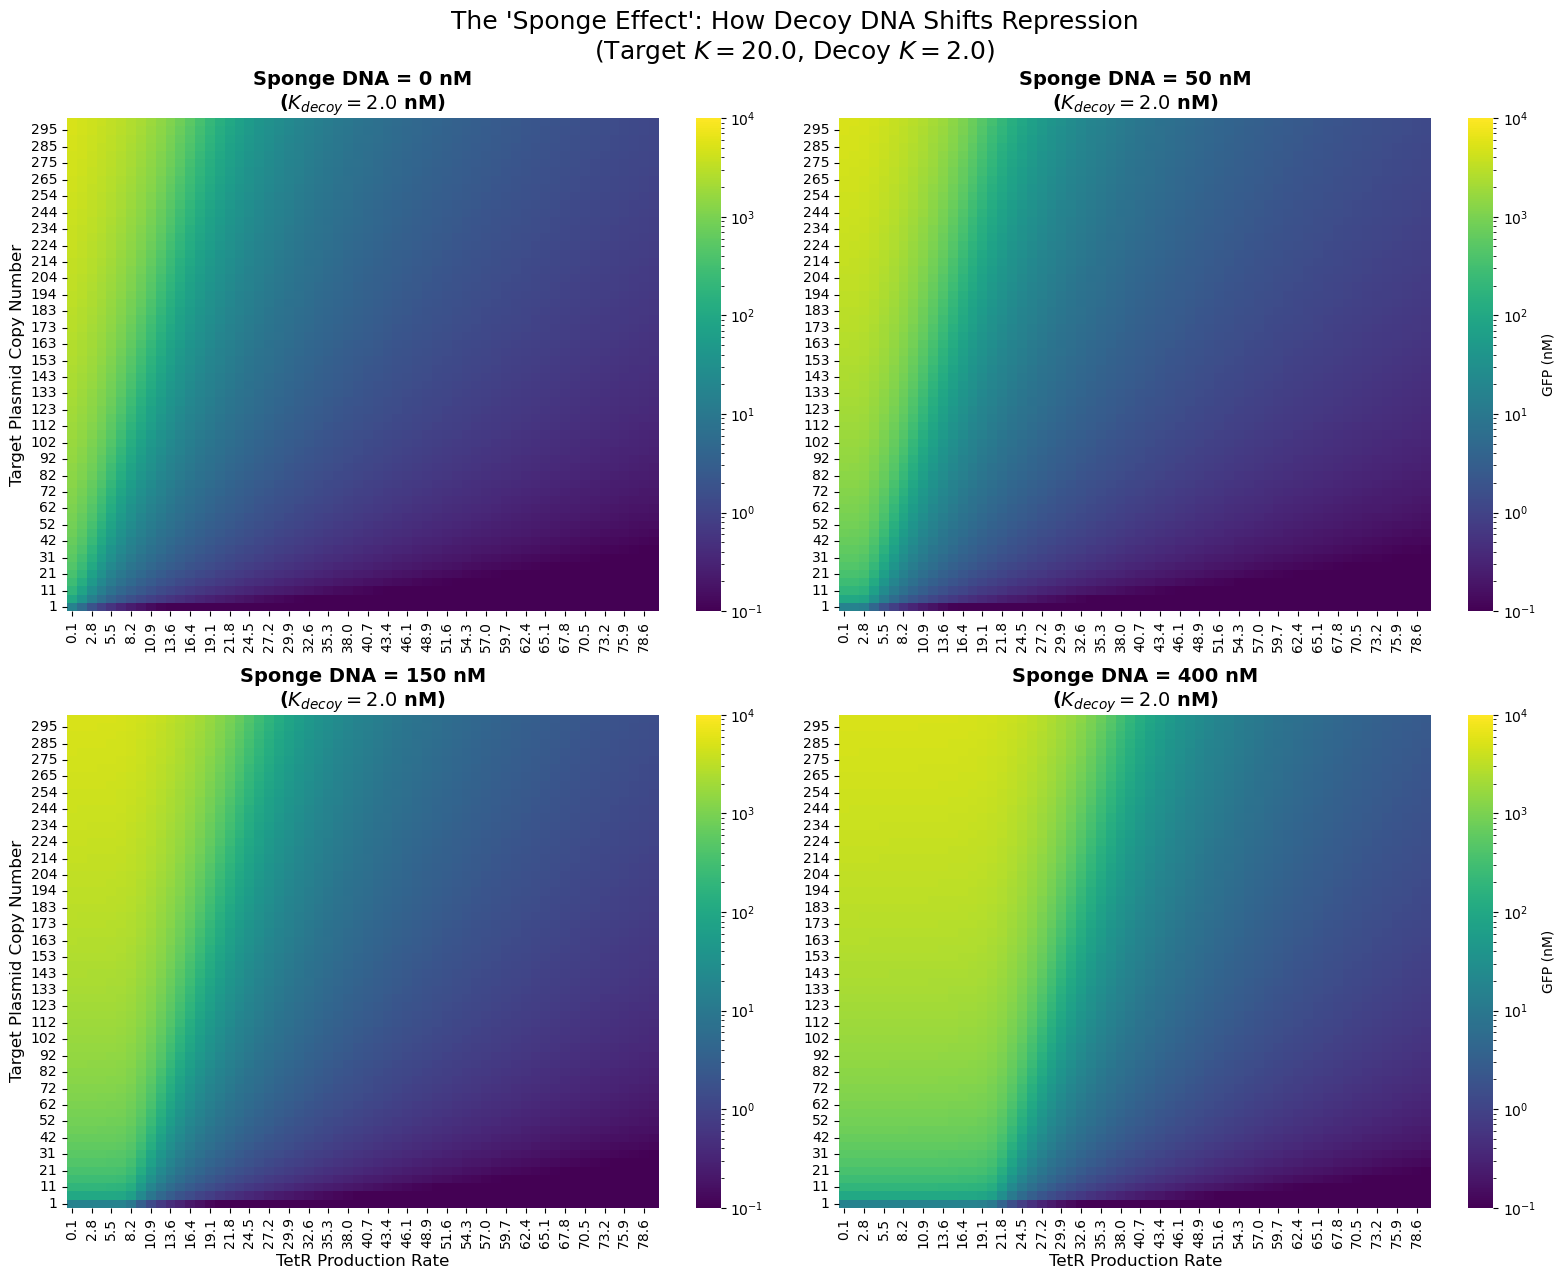

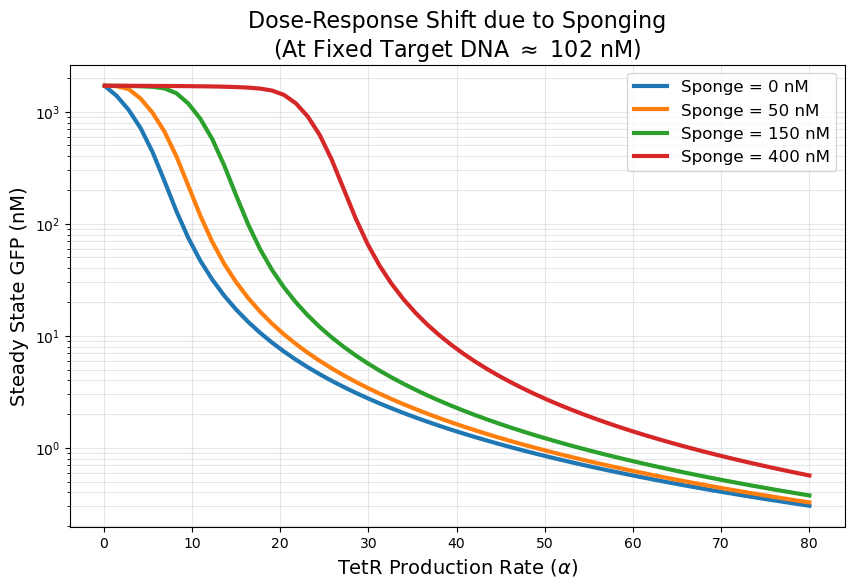

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.optimize import brentq
from matplotlib.colors import LogNorm

# --- 1. Global Parameters ---
n = 2.0                 # Hill coefficient
delta_tetR = 0.05       # Degradation rate of TetR
delta_GFP = 0.03        # Degradation rate of GFP
k_prod_per_plasmid = 0.5 # GFP production rate per copy

# --- 2. Parameters for Affinities ---
# Target (GFP) Affinity
K_target = 20.0 

# Decoy (Sponge) Affinity
# You can change this! 
# If K_decoy < K_target, the sponge is a "high affinity sink" (steals TetR easily).
# If K_decoy > K_target, the sponge is weak.
K_decoy = 2.0  

# --- 3. The Multi-Species Solver ---
def solve_free_tetR_with_sponge(R_total, D_target, K_target, D_decoy, K_decoy, n):
    """
    Solves for Free TetR accounting for TWO types of DNA binding sites.
    """
    if R_total <= 0: return 0.0

    def equation(r):
        # Occupancy of Target (GFP) sites
        occ_target = (r / K_target)**n / (1 + (r / K_target)**n)
        
        # Occupancy of Decoy (Sponge) sites
        occ_decoy = (r / K_decoy)**n / (1 + (r / K_decoy)**n)
        
        # Mass Balance: Free + Bound_Target + Bound_Decoy - Total = 0
        return r + (D_target * occ_target) + (D_decoy * occ_decoy) - R_total

    # R_free must be between 0 and R_total
    try:
        return brentq(equation, 0, R_total)
    except ValueError:
        return 0.0

# --- 4. Simulation Setup ---
# We will test specific concentrations of the Sponging DNA
decoy_concentrations = [0, 50, 150, 400] # nM of decoy DNA

# Axes for the heatmaps
tetR_rates = np.linspace(0.1, 80.0, 60)   # X-axis: TetR Production
target_dna_copies = np.linspace(1, 300, 60) # Y-axis: Target Plasmid Copy Number

# Storage for line plot later
line_plot_data = {}

# --- 5. Generate 4-Panel Heatmap ---
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()

# Fixed color scale for comparison
vmin, vmax = 0.1, 10000 

for idx, D_sponge in enumerate(decoy_concentrations):
    ax = axes[idx]
    
    # Grid for results
    gfp_matrix = np.zeros((len(target_dna_copies), len(tetR_rates)))
    
    for i, D_t in enumerate(target_dna_copies):
        for j, alpha in enumerate(tetR_rates):
            
            # 1. Total TetR
            R_tot = alpha / delta_tetR
            
            # 2. Free TetR (Considering Sponge)
            R_free = solve_free_tetR_with_sponge(R_tot, D_t, K_target, D_sponge, K_decoy, n)
            
            # 3. Active Target DNA (Sponge DNA does NOT contribute to GFP)
            frac_active = 1.0 / (1.0 + (R_free / K_target)**n)
            D_target_active = D_t * frac_active
            
            # 4. GFP Output
            gfp_ss = (k_prod_per_plasmid * D_target_active) / delta_GFP
            gfp_matrix[i, j] = gfp_ss
            
            # Save a specific slice for the line plot (e.g., Target Copy = 100)
            if i == 20: # arbitrary index for line plot later
                slice_target_conc = D_t
                if D_sponge not in line_plot_data:
                    line_plot_data[D_sponge] = []
                line_plot_data[D_sponge].append(gfp_ss)

    # Plot Heatmap
    df = pd.DataFrame(gfp_matrix, 
                      index=np.round(target_dna_copies, 0).astype(int), 
                      columns=np.round(tetR_rates, 1))
    
    sns.heatmap(df, ax=ax, cmap='viridis', 
                norm=LogNorm(vmin=vmin, vmax=vmax),
                cbar_kws={'label': 'GFP (nM)'} if idx % 2 != 0 else None)
    
    ax.set_title(f"Sponge DNA = {D_sponge} nM\n($K_{{decoy}}={K_decoy}$ nM)", fontsize=14, weight='bold')
    ax.invert_yaxis()
    
    if idx >= 2: ax.set_xlabel("TetR Production Rate", fontsize=12)
    if idx % 2 == 0: ax.set_ylabel("Target Plasmid Copy Number", fontsize=12)

plt.suptitle(f"The 'Sponge Effect': How Decoy DNA Shifts Repression\n(Target $K={K_target}$, Decoy $K={K_decoy}$)", fontsize=18)
plt.tight_layout()
plt.show()

# --- 6. Generate Line Plot (Cross Section) ---
# This visualizes the shift in the dose-response curve
plt.figure(figsize=(10, 6))

for D_sponge, gfp_values in line_plot_data.items():
    plt.plot(tetR_rates, gfp_values, linewidth=3, label=f'Sponge = {D_sponge} nM')

plt.title(f"Dose-Response Shift due to Sponging\n(At Fixed Target DNA $\\approx$ {int(slice_target_conc)} nM)", fontsize=16)
plt.xlabel("TetR Production Rate ($\\alpha$)", fontsize=14)
plt.ylabel("Steady State GFP (nM)", fontsize=14)
plt.yscale('log')
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=12)
plt.show()

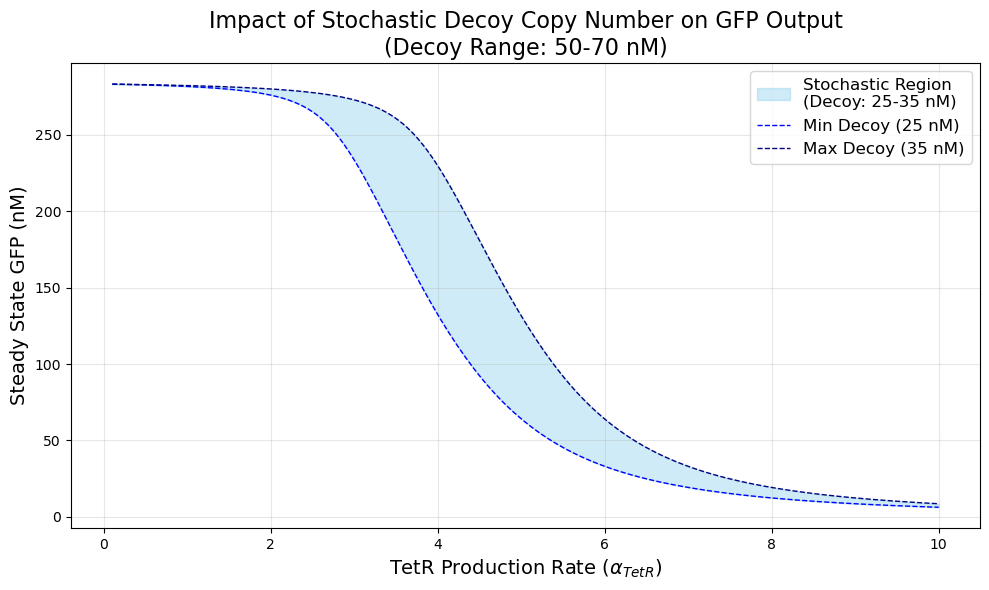

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# --- 1. Model Parameters ---
# Constants
n = 2.0                 # Hill coefficient
delta_tetR = 0.05       # Degradation rate of TetR
delta_GFP = 0.03        # Degradation rate of GFP
k_prod_per_plasmid = 0.5 

# Affinities
K_target = 20.0  # Affinity for the Gene of Interest
K_decoy = 2.0   # Affinity for the Decoy/Sponge

# Target Gene Setup (Fixed)
# Let's assume the Target GFP is on a chromosome or low copy plasmid
target_dna_conc = 17.0 # nM

# Stochastic Decoy Setup (Variable)
decoy_min = 50 # nM
decoy_max = 70 # nM

# --- 2. The Solver ---
def solve_free_tetR_with_sponge(R_total, D_target, K_target, D_decoy, K_decoy, n):
    """
    Solves for Free TetR accounting for Target + Sponge binding.
    """
    if R_total <= 0: return 0.0

    def equation(r):
        # Occupancy of Target
        occ_target = (r / K_target)**n / (1 + (r / K_target)**n)
        # Occupancy of Decoy
        occ_decoy = (r / K_decoy)**n / (1 + (r / K_decoy)**n)
        
        # Mass Balance
        return r + (D_target * occ_target) + (D_decoy * occ_decoy) - R_total

    try:
        return brentq(equation, 0, R_total)
    except ValueError:
        return 0.0

# --- 3. Simulation ---
# Generate a range of TetR production rates (The Dose)
tetR_rates = np.linspace(0.1, 10, 200)

gfp_lower_bound = [] # Corresponds to HIGH Decoy (35 nM) -> Weaker Repression -> Higher GFP? 
                     # Wait! Logic check:
                     # High Decoy (35) -> More sponge -> Less Free TetR -> Less Repression -> HIGHER GFP.
                     # Low Decoy (25) -> Less sponge -> More Free TetR -> More Repression -> LOWER GFP.

gfp_results_min_decoy = [] # Decoy = 25 (This will be the bottom curve)
gfp_results_max_decoy = [] # Decoy = 35 (This will be the top curve)

for alpha in tetR_rates:
    R_tot = alpha / delta_tetR
    
    # 1. Calculate Scenario A: Minimum Decoy (25 nM) -> Best Repression
    R_free_min = solve_free_tetR_with_sponge(R_tot, target_dna_conc, K_target, decoy_min, K_decoy, n)
    active_target_min = target_dna_conc / (1.0 + (R_free_min / K_target)**n)
    gfp_val_min_decoy = (k_prod_per_plasmid * active_target_min) / delta_GFP
    gfp_results_min_decoy.append(gfp_val_min_decoy)
    
    # 2. Calculate Scenario B: Maximum Decoy (35 nM) -> Worst Repression
    R_free_max = solve_free_tetR_with_sponge(R_tot, target_dna_conc, K_target, decoy_max, K_decoy, n)
    active_target_max = target_dna_conc / (1.0 + (R_free_max / K_target)**n)
    gfp_val_max_decoy = (k_prod_per_plasmid * active_target_max) / delta_GFP
    gfp_results_max_decoy.append(gfp_val_max_decoy)

# Convert to numpy arrays for easier plotting
gfp_results_min_decoy = np.array(gfp_results_min_decoy)
gfp_results_max_decoy = np.array(gfp_results_max_decoy)

# --- 4. Plotting ---
plt.figure(figsize=(10, 6))

# Plot the area
plt.fill_between(tetR_rates, gfp_results_min_decoy, gfp_results_max_decoy, 
                 color='skyblue', alpha=0.4, 
                 label='Stochastic Region\n(Decoy: 25-35 nM)')

# Plot the boundaries
plt.plot(tetR_rates, gfp_results_min_decoy, color='blue', linestyle='--', linewidth=1, label='Min Decoy (25 nM)')
plt.plot(tetR_rates, gfp_results_max_decoy, color='navy', linestyle='--', linewidth=1, label='Max Decoy (35 nM)')

# Calculate stoichiometric lines for context
# Total DNA load = Target + Decoy
total_load_min = (target_dna_conc + decoy_min) * delta_tetR
total_load_max = (target_dna_conc + decoy_max) * delta_tetR

# Add vertical lines showing where the "Titration Cliff" occurs
#plt.axvline(total_load_min, color='blue', linestyle=':', alpha=0.5)
#plt.axvline(total_load_max, color='navy', linestyle=':', alpha=0.5)
#plt.text(total_load_min, max(gfp_results_max_decoy)*0.6, " Saturation\n (25 nM Decoy)", color='blue', fontsize=9, rotation=90)
#plt.text(total_load_max, max(gfp_results_max_decoy)*0.2, " Saturation\n (35 nM Decoy)", color='navy', fontsize=9, rotation=90)


plt.title(f"Impact of Stochastic Decoy Copy Number on GFP Output\n(Decoy Range: {decoy_min}-{decoy_max} nM)", fontsize=16)
plt.xlabel("TetR Production Rate ($\\alpha_{TetR}$)", fontsize=14)
plt.ylabel("Steady State GFP (nM)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

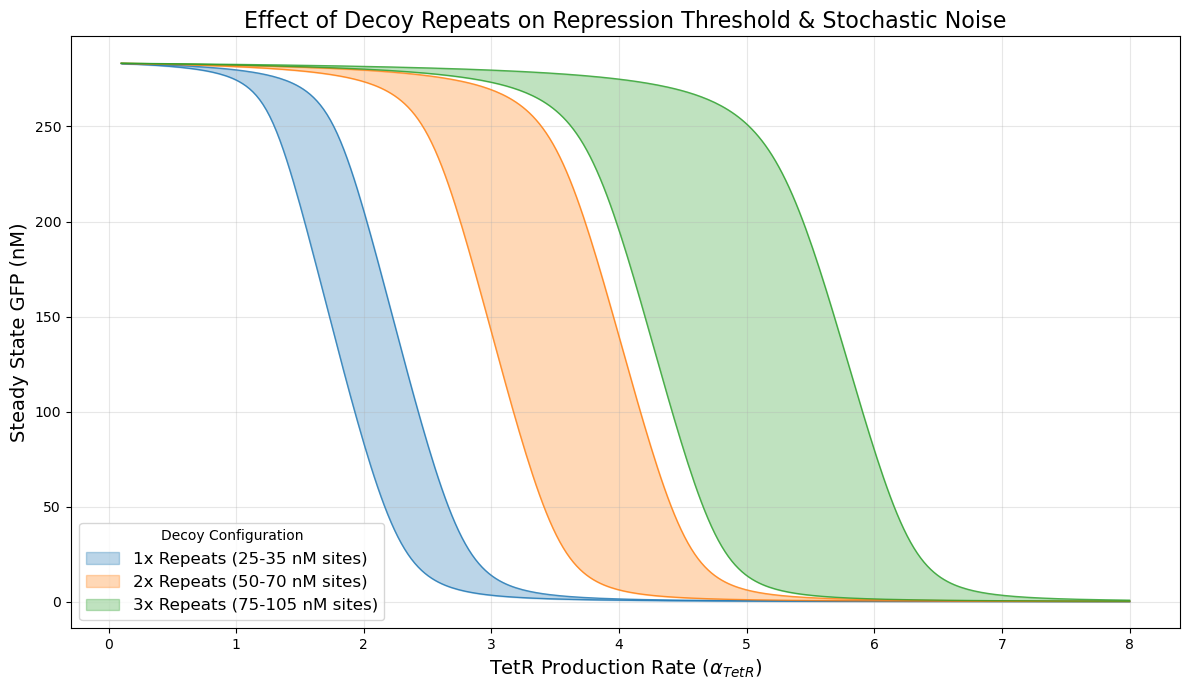

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# --- 1. Model Parameters ---
# Constants
n = 2.0                 # Hill coefficient
delta_tetR = 0.05       # Degradation rate of TetR
delta_GFP = 0.03        # Degradation rate of GFP
k_prod_per_plasmid = 0.5 

# Affinities (Assumed same for Target and Decoy repeats for this test)
K_target = 2.0  
K_decoy = 0.2   

# Target Gene (Fixed)
target_dna_conc = 17.0 # nM

# Stochastic Plasmid Copy Number Range
plasmid_copy_min = 25.0 # nM
plasmid_copy_max = 35.0 # nM

# Repeats to test
repeat_scenarios = [1, 2, 3]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

# --- 2. The Solver ---
def solve_free_tetR_with_sponge(R_total, D_target, K_target, D_decoy, K_decoy, n):
    """
    Solves for Free TetR accounting for Target + Decoy binding.
    """
    if R_total <= 0: return 0.0

    def equation(r):
        occ_target = (r / K_target)**n / (1 + (r / K_target)**n)
        occ_decoy = (r / K_decoy)**n / (1 + (r / K_decoy)**n)
        return r + (D_target * occ_target) + (D_decoy * occ_decoy) - R_total

    try:
        return brentq(equation, 0, R_total)
    except ValueError:
        return 0.0

# --- 3. Simulation & Plotting ---
plt.figure(figsize=(12, 7))

# Range of TetR production to simulate (Needs to be higher to saturate 3 repeats)
# Max sites ~ 105 nM. Max TetR needed ~ 105 * delta = 5.5. So we go to 8.0
tetR_rates = np.linspace(0.1, 8.0, 300)

for idx, repeats in enumerate(repeat_scenarios):
    color = colors[idx]
    
    # Calculate Effective Concentration of Binding Sites
    decoy_sites_min = plasmid_copy_min * repeats
    decoy_sites_max = plasmid_copy_max * repeats
    
    gfp_min_load = [] # Case: Minimum Sponge Sites (High GFP)
    gfp_max_load = [] # Case: Maximum Sponge Sites (Higher Repression Lag)
    
    for alpha in tetR_rates:
        R_tot = alpha / delta_tetR
        
        # Scenario A: Lowest Plasmid Copy Number (25)
        # Less sponge -> Repression happens earlier
        R_free_A = solve_free_tetR_with_sponge(R_tot, target_dna_conc, K_target, decoy_sites_min, K_decoy, n)
        active_target_A = target_dna_conc / (1.0 + (R_free_A / K_target)**n)
        gfp_A = (k_prod_per_plasmid * active_target_A) / delta_GFP
        gfp_min_load.append(gfp_A)
        
        # Scenario B: Highest Plasmid Copy Number (35)
        # More sponge -> Repression is delayed (buffered)
        R_free_B = solve_free_tetR_with_sponge(R_tot, target_dna_conc, K_target, decoy_sites_max, K_decoy, n)
        active_target_B = target_dna_conc / (1.0 + (R_free_B / K_target)**n)
        gfp_B = (k_prod_per_plasmid * active_target_B) / delta_GFP
        gfp_max_load.append(gfp_B)

    # Plotting the "Corridor of Uncertainty"
    # Note: gfp_min_load (from min sponge) is actually the "Left" curve (Lower TetR needed to repress)
    #       gfp_max_load (from max sponge) is the "Right" curve (More TetR needed to repress)
    # Wait, let's re-verify: 
    # Min Sponge (25) -> Saturation happens at TetR=25. -> Curve drops earlier.
    # Max Sponge (35) -> Saturation happens at TetR=35. -> Curve drops later.
    # So gfp_max_load is physically "higher" GFP for longer.
    
    label_text = f"{repeats}x Repeats ({int(decoy_sites_min)}-{int(decoy_sites_max)} nM sites)"
    
    plt.fill_between(tetR_rates, gfp_min_load, gfp_max_load, 
                     color=color, alpha=0.3, label=label_text)
    
    # Add solid boundary lines for clarity
    plt.plot(tetR_rates, gfp_min_load, color=color, linewidth=1, alpha=0.8)
    plt.plot(tetR_rates, gfp_max_load, color=color, linewidth=1, alpha=0.8)
    
    # Add Stoichiometric Indicators (Optional: Just for the centers)
    center_sites = (decoy_sites_min + decoy_sites_max) / 2
    center_alpha = (center_sites + target_dna_conc) * delta_tetR
    #plt.axvline(center_alpha, color=color, linestyle=':', alpha=0.5)
    #plt.text(center_alpha, max(gfp_min_load)* (0.9 - idx*0.1), f" Avg Saturation\n ({repeats}x)", 
    #         color=color, ha='right', fontsize=9, rotation=90)

# --- 4. Formatting ---
plt.title("Effect of Decoy Repeats on Repression Threshold & Stochastic Noise", fontsize=16)
plt.xlabel("TetR Production Rate ($\\alpha_{TetR}$)", fontsize=14)
plt.ylabel("Steady State GFP (nM)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(title="Decoy Configuration", fontsize=12, loc='lower left')

# Add "ON" and "OFF" annotations
#plt.text(0.5, 300, "Gene ON\n(Sponge Unsaturated)", fontsize=12, ha='center', color='grey')
#plt.text(7.0, 50, "Gene OFF\n(Sponge Saturated)", fontsize=12, ha='center', color='grey')

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

def create_windowed_data(y_series, x_series, p, f):
    indices = range(p, len(y_series) - f)
    Y_p = np.array([y_series[t-p : t] for t in indices])
    Y_f = np.array([y_series[t : t+f] for t in indices])
    X_p = np.array([x_series[t-p : t+f] for t in indices]) # Input history + future
    return Y_p, Y_f, X_p

def calculate_predictive_certainty(y_series, x_series, p, f):
    # 1. Prepare Data
    Y_p, Y_f, X_all = create_windowed_data(y_series, x_series, p, f)
    
    # Split into Train/Test to ensure we measure real "certainty," not overfitting
    split = int(len(Y_p) * 0.8)
    train_Yp, test_Yp = Y_p[:split], Y_p[split:]
    train_Yf, test_Yf = Y_f[:split], Y_f[split:]
    train_X,  test_X  = X_all[:split], X_all[split:]

    # 2. Baseline Model: Y_f ~ f(Y_p)
    # We use a Multi-output Random Forest to predict the entire future vector
    model_base = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1)
    model_base.fit(train_Yp, train_Yf)
    pred_base = model_base.predict(test_Yp)
    mse_base = mean_squared_error(test_Yf, pred_base)

    # 3. Full Model: Y_f ~ f(Y_p, X_all)
    # Concatenate history and input signals
    train_combined = np.hstack([train_Yp, train_X])
    test_combined = np.hstack([test_Yp, test_X])
    
    model_full = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1)
    model_full.fit(train_combined, train_Yf)
    pred_full = model_full.predict(test_combined)
    mse_full = mean_squared_error(test_Yf, pred_full)

    # 4. Certainty Gain (U)
    # How much of the remaining uncertainty was removed by X?
    u_score = 1 - (mse_full / mse_base)
    
    return max(0, u_score)

# --- Example with a very clear effect ---
T = 5000
p, f = 15, 15
x = np.random.randint(0, 2, T)
y = np.zeros(T)
for t in range(5, T):
    # Y is purely driven by X, but with a complex non-linear delay
    # Past Y provides NO info, only X does.
    y[t] = 2.0 * x[t-3] * x[t-5] + np.random.normal(0, 0.1)

u = calculate_predictive_certainty(y, x, p, f)
print(f"Predictive Certainty Gain (U): {u:.4f}")

Predictive Certainty Gain (U): 0.8085
